# Simulating ML Model Deployment Strategies
Deploying a new machine learning model to production is one of the most critical stages of the ML lifecycle. Even if a model performs well on validation and test datasets, directly replacing the existing production model can be risky. Offline evaluation rarely captures the full complexity of real-world environments—data distributions may shift, user behavior can change, and system constraints in production may differ from those in controlled experiments.

As a result, a model that appears superior during development might still degrade performance or negatively impact user experience once deployed. To mitigate these risks, ML teams adopt controlled rollout strategies that allow them to evaluate new models under real production conditions while minimizing potential disruptions.


## Setting Up
Before simulating any strategy, we need two things: a way to represent incoming requests, and a stand-in for each model.

Each model is simply a function that takes a request and returns a score — a number that loosely represents how good that model's recommendation is. The legacy model's score is capped at 0.35, while the candidate model's is capped at 0.55, making the candidate intentionally better so we can verify that each strategy actually detects the improvement.

make_requests() generates 200 requests spread across 40 users, which gives us enough traffic to see meaningful differences between strategies while keeping the simulation lightweight.

In [10]:
import random
import hashlib

random.seed(42)

In [11]:
# A "model" is just a function: request → prediction score.
# quality = probability that a recommendation gets clicked.

def legacy_model(request):
    return {"model": "legacy",    "score": random.random() * 0.35}

def candidate_model(request):
    return {"model": "candidate", "score": random.random() * 0.55}

def make_requests(n=200):
    users = [f"user_{i}" for i in range(40)]
    return [{"id": f"req_{i}", "user": random.choice(users)} for i in range(n)]

requests = make_requests()

## A/B Testing
ab_route() is the core of this strategy — for every incoming request, it draws a random number and routes to the candidate model only if that number falls below 0.10, otherwise the request goes to legacy. This gives the candidate roughly 10% of traffic.

We then collect the prediction scores from each model separately and compute the average at the end. In a real system, these scores would be replaced by actual engagement metrics like click-through rate or watch time — here the score just stands in for "how good was this recommendation."
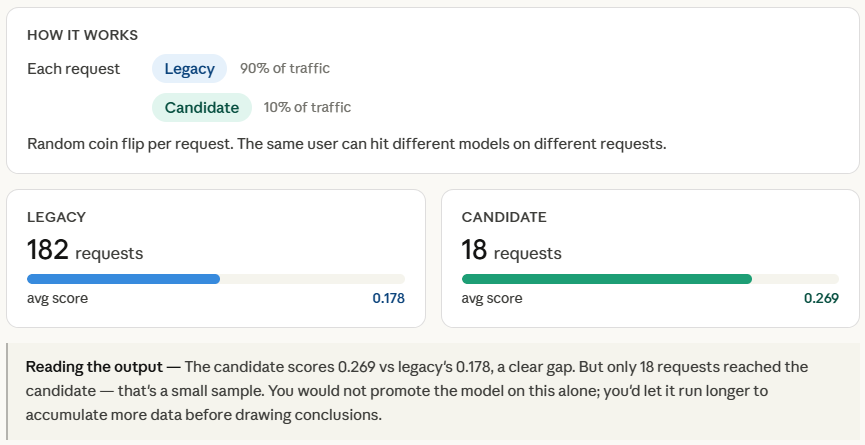

In [12]:
print("── 1. A/B Testing ──────────────────────────────────────────")

CANDIDATE_TRAFFIC = 0.10   # 10 % of requests go to candidate

def ab_route(request):
    return candidate_model if random.random() < CANDIDATE_TRAFFIC else legacy_model

results = {"legacy": [], "candidate": []}
for req in requests:
    model  = ab_route(req)
    pred   = model(req)
    results[pred["model"]].append(pred["score"])

for name, scores in results.items():
    print(f"  {name:12s} | requests: {len(scores):3d} | avg score: {sum(scores)/len(scores):.3f}")

── 1. A/B Testing ──────────────────────────────────────────
  legacy       | requests: 182 | avg score: 0.178
  candidate    | requests:  18 | avg score: 0.269


## Canary Testing
The key function here is get_canary_users(), which uses an MD5 hash to deterministically assign users to the canary group. The important word is deterministic — sorting users by their hash means the same users always end up in the canary group across runs, which mirrors how real canary deployments work where a specific user consistently sees the same model.

We then simulate three phases by simply expanding the fraction of canary users — 5%, 20%, and 50%. For each request, routing is decided by whether the user belongs to the canary group, not by a random coin flip like in A/B testing. This is the fundamental difference between the two strategies: A/B testing splits by request, canary testing splits by user.
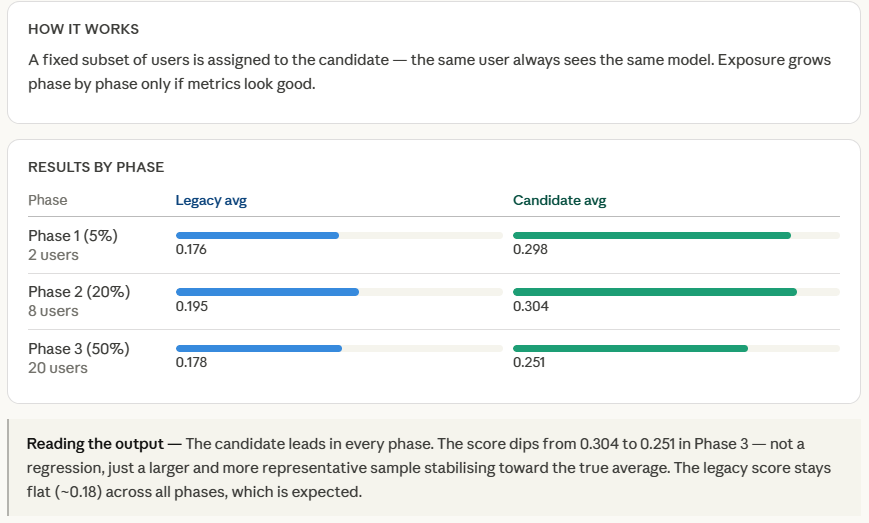

In [13]:
print("\n── 2. Canary Testing ───────────────────────────────────────")

def get_canary_users(all_users, fraction):
    """Deterministic user assignment via hash — stable across restarts."""
    n = max(1, int(len(all_users) * fraction))
    ranked = sorted(all_users, key=lambda u: hashlib.md5(u.encode()).hexdigest())
    return set(ranked[:n])

all_users = list(set(r["user"] for r in requests))

for phase, fraction in [("Phase 1 (5%)", 0.05), ("Phase 2 (20%)", 0.20), ("Phase 3 (50%)", 0.50)]:
    canary_users = get_canary_users(all_users, fraction)
    scores = {"legacy": [], "candidate": []}
    for req in requests:
        model = candidate_model if req["user"] in canary_users else legacy_model
        pred  = model(req)
        scores[pred["model"]].append(pred["score"])
    print(f"  {phase} | canary users: {len(canary_users):2d} "
          f"| legacy avg: {sum(scores['legacy'])/max(1,len(scores['legacy'])):.3f} "
          f"| candidate avg: {sum(scores['candidate'])/max(1,len(scores['candidate'])):.3f}")



── 2. Canary Testing ───────────────────────────────────────
  Phase 1 (5%) | canary users:  2 | legacy avg: 0.176 | candidate avg: 0.298
  Phase 2 (20%) | canary users:  8 | legacy avg: 0.195 | candidate avg: 0.304
  Phase 3 (50%) | canary users: 20 | legacy avg: 0.178 | candidate avg: 0.251


## Interleaved Testing
Both models run on every request, and interleave() merges their outputs by alternating items — one from legacy, one from candidate, one from legacy, and so on. Each item is tagged with its source model, so when a user clicks something, we know exactly which model to credit.

The small random.uniform(-0.05, 0.05) noise added to each item's score simulates the natural variation you'd see in real recommendations — two items from the same model won't have identical quality.

At the end, we compute CTR separately for each model's items. Because both models competed on the same requests against the same users at the same time, there is no confounding factor — any difference in CTR is purely down to model quality. This is what makes interleaved testing the most statistically clean comparison of the four strategies.
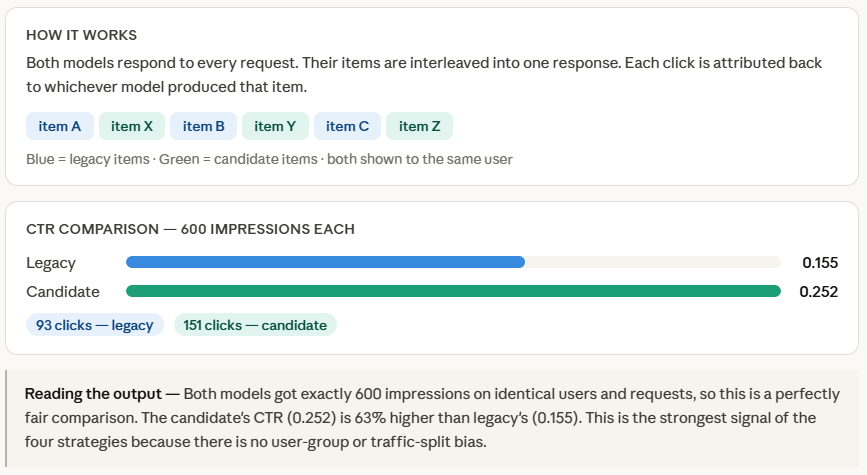

In [14]:
print("\n── 3. Interleaved Testing ──────────────────────────────────")

def interleave(pred_a, pred_b):
    """Alternate items: A, B, A, B … tagged with their source model."""
    items_a = [("legacy",    pred_a["score"] + random.uniform(-0.05, 0.05)) for _ in range(3)]
    items_b = [("candidate", pred_b["score"] + random.uniform(-0.05, 0.05)) for _ in range(3)]
    merged  = []
    for a, b in zip(items_a, items_b):
        merged += [a, b]
    return merged

clicks = {"legacy": 0, "candidate": 0}
shown  = {"legacy": 0, "candidate": 0}

for req in requests:
    pred_l = legacy_model(req)
    pred_c = candidate_model(req)
    for source, score in interleave(pred_l, pred_c):
        shown[source]  += 1
        clicks[source] += int(random.random() < score)   # click ~ score

for name in ["legacy", "candidate"]:
    print(f"  {name:12s} | impressions: {shown[name]:4d} "
          f"| clicks: {clicks[name]:3d} "
          f"| CTR: {clicks[name]/shown[name]:.3f}")



── 3. Interleaved Testing ──────────────────────────────────
  legacy       | impressions:  600 | clicks:  93 | CTR: 0.155
  candidate    | impressions:  600 | clicks: 151 | CTR: 0.252


## Shadow Testing
Both models run on every request, but the loop makes a clear distinction — live_pred is what the user gets, shadow_pred goes straight into the log and nothing more. The candidate's output is never returned, never shown, never acted on.
The log list is the entire point of shadow testing. In a real system this would be written to a database or a data warehouse, and engineers would later query it to compare latency distributions, output patterns, or score distributions against the legacy model — all without a single user being affected.
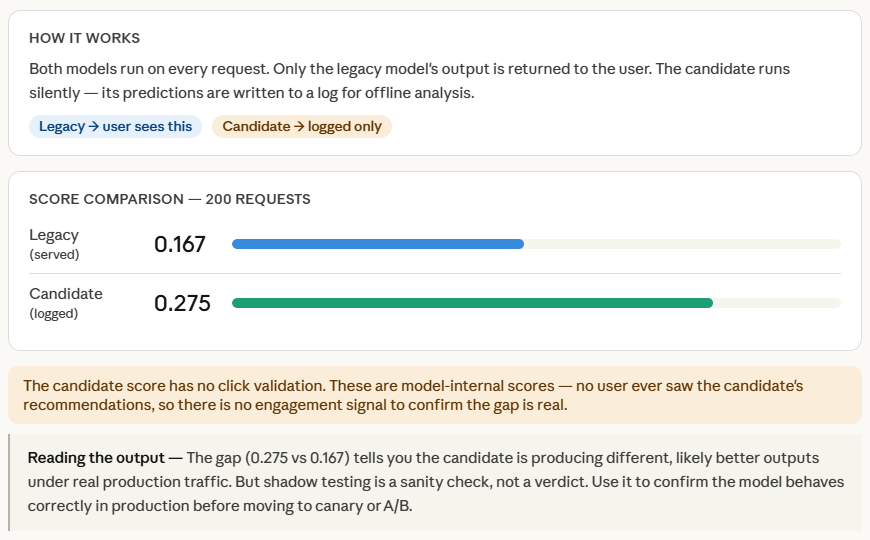

In [15]:
print("\n── 4. Shadow Testing ───────────────────────────────────────")

log = []   # candidate's shadow log

for req in requests:
    # What the user sees
    live_pred   = legacy_model(req)

    # Shadow run — never shown to user
    shadow_pred = candidate_model(req)

    log.append({
        "request_id":       req["id"],
        "legacy_score":     live_pred["score"],
        "candidate_score":  shadow_pred["score"],    # logged, not served
    })

avg_legacy    = sum(r["legacy_score"]    for r in log) / len(log)
avg_candidate = sum(r["candidate_score"] for r in log) / len(log)

print(f"  Legacy    avg score (served):  {avg_legacy:.3f}")
print(f"  Candidate avg score (logged):  {avg_candidate:.3f}")
print(f"  Note: candidate score has no click validation — shadow only.")



── 4. Shadow Testing ───────────────────────────────────────
  Legacy    avg score (served):  0.167
  Candidate avg score (logged):  0.275
  Note: candidate score has no click validation — shadow only.
